In [1]:
"""Polar chromagram: YTB-003 HEAD_IN region, Circle of Fifths visualization."""

import json
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, HTML, display
import ipywidgets as widgets

from dijon.global_config import RAW_AUDIO_DIR, AUDIO_MARKERS_DIR
from dijon.novelty import compute_novelty_spectrum
from dijon.tempogram import compute_tempogram_fourier
from dijon.beats import compute_beat_sequence, estimate_beats_per_bar, label_bars_and_beats
from dijon.chromagram import metric_chromagram

In [2]:
# Load YTB-005 audio and trim to HEAD_IN_START -> HEAD_IN_END
track = "YTB-005"
audio_path = RAW_AUDIO_DIR / f"{track}.wav"
markers_path = AUDIO_MARKERS_DIR / f"{track}_markers.json"

with open(markers_path, encoding="utf-8") as f:
    payload = json.load(f)
markers = payload["markers"]
start_sec = next(m["position"] for m in markers if m["name"] == "HEAD_IN_START")
end_sec = next(m["position"] for m in markers if m["name"] == "HEAD_IN_END")

y_full, sr = librosa.load(audio_path, sr=None, mono=True)
start_ix = int(start_sec * sr)
end_ix = int(end_sec * sr)
y = y_full[start_ix:end_ix]

print(f"Region: {start_sec:.2f}s -> {end_sec:.2f}s ({len(y)/sr:.2f}s)")

Region: 23.17s -> 63.83s (40.66s)


In [3]:
# Novelty (spectrum, CLI defaults)
novelty, novelty_fs = compute_novelty_spectrum(
    y, Fs=sr, N=1024, H=256, gamma=100.0, M=10, norm=True, Fs_target=100.0
)
print(f"Novelty: {len(novelty)} samples @ {novelty_fs} Hz")

Novelty: 4066 samples @ 100.0 Hz


In [4]:
# Tempogram (fourier, CLI defaults)
FS_NOV = 100.0
Theta = np.arange(40, 321, dtype=float)
X_temp, _T, _F = compute_tempogram_fourier(novelty, FS_NOV, N=512, H=1, Theta=Theta)
tempogram = np.abs(X_temp)
print(f"Tempogram shape: {tempogram.shape}")

Tempogram shape: (281, 4067)


In [5]:
# Beats (from tempogram + novelty)
tempo_profile = np.mean(tempogram, axis=1)
tempo_bpm = float(Theta[int(np.argmax(tempo_profile))])
beat_ref = int(np.round(FS_NOV * 60.0 / tempo_bpm))
B = compute_beat_sequence(novelty, beat_ref=beat_ref, factor=1.0)
beat_times = B / FS_NOV
print(f"Implied BPM: {tempo_bpm:.1f}, {len(beat_times)} beats")

Implied BPM: 284.0, 195 beats


In [6]:
# Meter (head_in=0 since trimmed audio starts at HEAD_IN_START)
head_in = 0.0
beats_per_bar, _low, _high = estimate_beats_per_bar(beat_times, head_in, y, sr)
labels = label_bars_and_beats(beat_times, head_in, beats_per_bar)
meter_map = labels  # shape (N, 3): [time_sec, bar_number, beat_number]
print(f"Beats per bar: {beats_per_bar}, labels shape: {meter_map.shape}")

Beats per bar: 4, labels shape: (195, 3)


In [7]:
# Metric chromagram (CLI defaults), then post-process for polar display
C_metric_raw = metric_chromagram(
    y,
    sr=sr,
    meter_map=meter_map,
    hop_length=256,
    bpm_threshold=180.0,
    chroma_type="cqt",
    aggregate="mean",
    accent_mode="preserve",
)

# Post-processing controls for the polar chromagram.
TOP_K_NOTES = 5
FRAME_ENERGY_THRESHOLD = 0.20  # relative to the max frame L2 norm before normalization
BIN_RELATIVE_THRESHOLD = 0.15  # relative to each frame's max retained note strength

C_metric = C_metric_raw.astype(float).copy()
frame_norms = np.linalg.norm(C_metric, axis=0)
frame_norm_threshold = FRAME_ENERGY_THRESHOLD * frame_norms.max() if frame_norms.size else 0.0

for i in range(C_metric.shape[1]):
    frame = C_metric[:, i].copy()

    # Discard silent / very low-energy frames entirely.
    if frame_norms[i] < frame_norm_threshold:
        C_metric[:, i] = 0.0
        continue

    # Keep only the top-k notes in this frame.
    keep_idx = np.argsort(frame)[-TOP_K_NOTES:]
    topk_mask = np.zeros_like(frame, dtype=bool)
    topk_mask[keep_idx] = True
    frame[~topk_mask] = 0.0

    # Suppress weak bins relative to the strongest surviving note.
    peak = frame.max()
    if peak <= 0:
        C_metric[:, i] = 0.0
        continue
    frame[frame < BIN_RELATIVE_THRESHOLD * peak] = 0.0

    # L2-normalize each frame vector.
    l2 = np.linalg.norm(frame)
    C_metric[:, i] = frame / l2 if l2 > 0 else 0.0

active_frames = int(np.count_nonzero(np.linalg.norm(C_metric, axis=0) > 0))
print(
    f"Chromagram shape: {C_metric.shape} (12 chroma x {C_metric.shape[1]} metric bins); "
    f"active frames after filtering: {active_frames}"
)


Chromagram shape: (12, 388) (12 chroma x 388 metric bins); active frames after filtering: 388


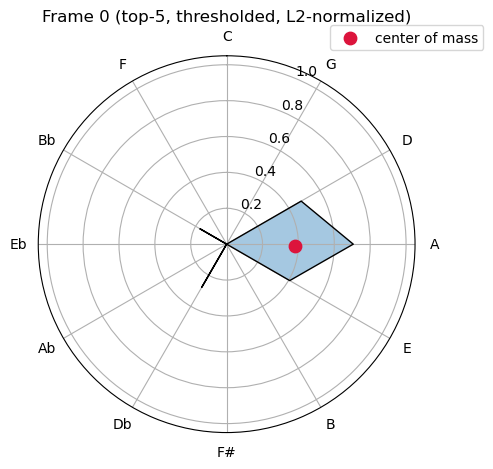

In [8]:
# Circle of Fifths: C, G, D, A, E, B, F#, Db, Ab, Eb, Bb, F (clockwise from 12 o'clock)
# librosa chroma order: C C# D D# E F F# G G# A A# B -> indices 0-11
P5_INDICES = [0, 7, 2, 9, 4, 11, 6, 1, 8, 3, 10, 5]
P5_NAMES = ["C", "G", "D", "A", "E", "B", "F#", "Db", "Ab", "Eb", "Bb", "F"]

def chroma_to_p5(chroma_col):
    """Reorder chroma column to Circle of Fifths (12 values)."""
    return np.asarray(chroma_col)[P5_INDICES]

def polar_center_of_mass(values, angles):
    """Return the center-of-mass point of a polar chroma profile."""
    values = np.asarray(values, dtype=float)
    mass = values.sum()
    if mass <= 0:
        return None
    x = np.sum((values ** 2) * np.cos(angles)) / mass
    y = np.sum((values ** 2) * np.sin(angles)) / mass
    radius = float(np.hypot(x, y))
    theta = float(np.arctan2(y, x))
    return theta, radius

# Static filled-radar plot for frame 0
frame_idx = 0
values = chroma_to_p5(C_metric[:, frame_idx])
angles = np.linspace(0, 2 * np.pi, 12, endpoint=False)
angles_closed = np.append(angles, angles[0])
values_closed = np.append(values, values[0])
com = polar_center_of_mass(values, angles)

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
ax.set_theta_offset(np.pi / 2)   # C at 12 o'clock
ax.set_theta_direction(-1)       # clockwise
ax.fill(angles_closed, values_closed, alpha=0.4)
ax.plot(angles_closed, values_closed, "k-", lw=1)
if com is not None:
    ax.scatter([com[0]], [com[1]], s=80, color="crimson", zorder=5, label="center of mass")
    ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
ax.set_xticks(angles)
ax.set_xticklabels(P5_NAMES)
ax.set_ylim(0, 1.05)
ax.set_title(f"Frame {frame_idx} (top-5, thresholded, L2-normalized)")
plt.tight_layout()
plt.show()


In [9]:
# Audio-synced polar chromagram
import base64
import io

from scipy.io import wavfile

# Rebuild the adaptive metric-bin boundaries so audio time maps to chromagram bins.
beat_times_metric = meter_map[:, 0].astype(float)
beat_durs = np.diff(beat_times_metric)
metric_boundary_times = [float(beat_times_metric[0])]
for i, dur in enumerate(beat_durs):
    start = float(beat_times_metric[i])
    end = float(beat_times_metric[i + 1])
    local_bpm = 60.0 / dur
    subdiv = 4 if local_bpm <= 180.0 else 2
    for k in range(1, subdiv):
        metric_boundary_times.append(start + (k / subdiv) * dur)
    metric_boundary_times.append(end)
metric_boundary_times = np.asarray(metric_boundary_times, dtype=float)

assert len(metric_boundary_times) - 1 == C_metric.shape[1]

C_display = C_metric.astype(float)
C_display_p5 = C_display[P5_INDICES, :].T.tolist()
boundary_times_js = metric_boundary_times.tolist()

# Encode the trimmed audio as an inline WAV for a self-contained notebook display.
audio_buf = io.BytesIO()
y_int16 = (np.clip(y, -1, 1) * 32767).astype(np.int16)
wavfile.write(audio_buf, sr, y_int16)
audio_b64 = base64.b64encode(audio_buf.getvalue()).decode("ascii")

audio_sync_html = f"""
<div id="polar-audio-wrap" style="max-width: 560px; font-family: sans-serif;">
  <audio id="polar-audio" controls style="width: 100%; margin-bottom: 12px;">
    <source src="data:audio/wav;base64,{audio_b64}" type="audio/wav">
  </audio>
  <div id="polar-status" style="margin-bottom: 8px; font-size: 14px;">Frame 1</div>
  <svg id="polar-svg" viewBox="0 0 360 360" width="100%" style="background: #fff; border: 1px solid #ddd; border-radius: 8px;"></svg>
</div>
<script>
(function() {{
  const noteNames = {json.dumps(['C', 'G', 'D', 'A', 'E', 'B', 'F#', 'Db', 'Ab', 'Eb', 'Bb', 'F'])};
  const frames = {json.dumps('REPLACE_FRAMES')};
  const boundaries = {json.dumps('REPLACE_BOUNDARIES')};
  const duration = {len(y) / sr:.12f};
  const audio = document.getElementById("polar-audio");
  const svg = document.getElementById("polar-svg");
  const status = document.getElementById("polar-status");

  const cx = 180, cy = 180, maxR = 120;
  let rafId = null;

  function polarPoint(index, value) {{
    const theta = -Math.PI / 2 + index * (2 * Math.PI / 12);
    const r = Math.max(0, Math.min(1, value)) * maxR;
    return [cx + r * Math.cos(theta), cy + r * Math.sin(theta)];
  }}

  function makePath(values) {{
    const pts = values.map((v, i) => polarPoint(i, v));
    return pts.map((pt, i) => `${{i === 0 ? 'M' : 'L'}} ${{pt[0].toFixed(2)}} ${{pt[1].toFixed(2)}}`).join(' ') + ' Z';
  }}

  function frameIndexForTime(t) {{
    for (let i = 0; i < boundaries.length - 1; i += 1) {{
      if (t >= boundaries[i] && t < boundaries[i + 1]) return i;
    }}
    return Math.max(0, frames.length - 1);
  }}

  function drawStatic() {{
    svg.innerHTML = '';

    [0.25, 0.5, 0.75, 1.0].forEach((frac) => {{
      const c = document.createElementNS('http://www.w3.org/2000/svg', 'circle');
      c.setAttribute('cx', cx);
      c.setAttribute('cy', cy);
      c.setAttribute('r', frac * maxR);
      c.setAttribute('fill', 'none');
      c.setAttribute('stroke', '#e0e0e0');
      c.setAttribute('stroke-width', '1');
      svg.appendChild(c);
    }});

    noteNames.forEach((name, i) => {{
      const theta = -Math.PI / 2 + i * (2 * Math.PI / 12);
      const spokeX = cx + maxR * Math.cos(theta);
      const spokeY = cy + maxR * Math.sin(theta);
      const labelX = cx + (maxR + 22) * Math.cos(theta);
      const labelY = cy + (maxR + 22) * Math.sin(theta);

      const line = document.createElementNS('http://www.w3.org/2000/svg', 'line');
      line.setAttribute('x1', cx);
      line.setAttribute('y1', cy);
      line.setAttribute('x2', spokeX);
      line.setAttribute('y2', spokeY);
      line.setAttribute('stroke', '#d0d0d0');
      line.setAttribute('stroke-width', '1');
      svg.appendChild(line);

      const text = document.createElementNS('http://www.w3.org/2000/svg', 'text');
      text.setAttribute('x', labelX);
      text.setAttribute('y', labelY + 4);
      text.setAttribute('text-anchor', 'middle');
      text.setAttribute('font-size', '14');
      text.textContent = name;
      svg.appendChild(text);
    }});

    const blob = document.createElementNS('http://www.w3.org/2000/svg', 'path');
    blob.setAttribute('id', 'polar-blob');
    blob.setAttribute('fill', 'rgba(52, 152, 219, 0.35)');
    blob.setAttribute('stroke', '#1f4e79');
    blob.setAttribute('stroke-width', '2');
    svg.appendChild(blob);
  }}

  function update() {{
    const t = Math.max(0, Math.min(duration, audio.currentTime || 0));
    const frameIdx = frameIndexForTime(t);
    const blob = document.getElementById('polar-blob');
    blob.setAttribute('d', makePath(frames[frameIdx]));
    status.textContent = `Frame ${{frameIdx + 1}} / ${{frames.length}}  time=${{t.toFixed(2)}}s`;
  }}

  function loop() {{
    update();
    if (!audio.paused && !audio.ended) rafId = requestAnimationFrame(loop);
  }}

  drawStatic();
  update();
  audio.addEventListener('play', () => loop());
  audio.addEventListener('pause', () => {{ if (rafId) cancelAnimationFrame(rafId); update(); }});
  audio.addEventListener('ended', () => {{ if (rafId) cancelAnimationFrame(rafId); update(); }});
  audio.addEventListener('seeked', update);
}})();
</script>
"""

audio_sync_html = audio_sync_html.replace(json.dumps('REPLACE_FRAMES'), json.dumps(C_display_p5))
audio_sync_html = audio_sync_html.replace(json.dumps('REPLACE_BOUNDARIES'), json.dumps(boundary_times_js))

display(HTML(audio_sync_html))


In [ ]:
# Aggregate harmonic blob: sum all processed chroma bins, then normalize to one summary profile
harmonic_blob = np.sum(C_metric, axis=1).astype(float)
harmonic_blob = harmonic_blob / np.max(harmonic_blob) if np.max(harmonic_blob) > 0 else harmonic_blob
harmonic_blob_p5 = chroma_to_p5(harmonic_blob)
harmonic_blob_closed = np.append(harmonic_blob_p5, harmonic_blob_p5[0])
com_blob = polar_center_of_mass(harmonic_blob_p5, angles)

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"})
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.fill(angles_closed, harmonic_blob_closed, alpha=0.45, color="#4C78A8")
ax.plot(angles_closed, harmonic_blob_closed, color="#1F4E79", lw=2)
if com_blob is not None:
    ax.scatter([com_blob[0]], [com_blob[1]], s=80, color="crimson", zorder=5, label="center of mass")
    ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
ax.set_xticks(angles)
ax.set_xticklabels(P5_NAMES)
ax.set_ylim(0, 1.05)
ax.set_title("Normalized Harmonic Blob (summed over filtered metric bins)")
plt.tight_layout()
plt.show()
